# 33. Алгоритм кластеризации Ллойда (K-средних, K-means)

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = [(98, 62), (80, 95), (71, 130), (89, 164), (137, 115), (107, 155), (109, 105), (174, 62), (183, 115), (164, 153),
     (142, 174), (140, 80), (308, 123), (229, 171), (195, 237), (180, 298), (179, 340), (251, 262), (300, 176),
     (346, 178), (311, 237), (291, 283), (254, 340), (215, 308), (239, 223), (281, 207), (283, 156)]

In [9]:
M = np.mean(x, axis=0)  #вычисление среднийх по каждой координате
D = np.var(x, axis=0)   #вычисление дисперсий по каждой координате

K = 2                   #число кластеров

ma = [np.random.normal(M, np.sqrt(D / 10), 2) for n in range(K)]    #начальные центры кластеров

ro = lambda x_vect, m_vect: np.mean((x_vect - m_vect) ** 2)         #евклидова метрика

colors =('green', 'blue', 'brown', 'black')                         #цветов должно быть не меньше кластеров

plt.ion()
n = 0

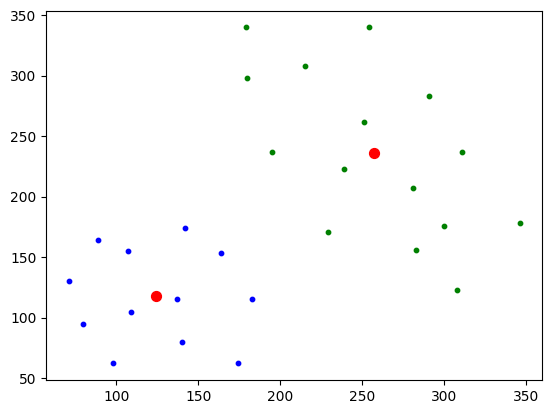

In [10]:
while n < 10:
    X = [[] for i in range(K)]                  # инициализация пустого двумерного списка для хранения объектов кластеров

    for x_vect in x:
        r = [ro(x_vect, m) for m in ma]         # вычисление расстояний для текущего образа до центров кластеров
        X[np.argmin(r)].append(x_vect)          # добавление образа к кластеру с ближайшим центром

    ma = [np.mean(xx, axis=0) for xx in X]      # пересчет центров кластеров

    n += 1


# отображение найденных кластеров
COLORS = ('green', 'blue', 'brown', 'black')     # цветов должно быть не меньше кластеров (>= K)
for i in range(K):
    xx = np.array(X[i]).T
    plt.scatter(xx[0], xx[1], s=10, color=COLORS[i])

# отображение центров кластеров
mx = [m[0] for m in ma]
my = [m[1] for m in ma]
plt.scatter(mx, my, s=50, color='red')

plt.show()